<div >
    <img src = "../banner.jpg" />
</div>

<a href="https://colab.research.google.com/github/ignaciomsarmiento/BDML_202610/blob/main/Lecture12/Notebook_NN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificando digitos con Redes Neuronales 

Uno de los conjuntos de datos ampliamente utilizados para la clasificación de imágenes es el conjunto de datos MNIST (LeCun et al., 1998) de dígitos escritos a mano. En el momento de su lanzamiento en la década de 1990, planteó un desafío formidable para la mayoría de los algoritmos de aprendizaje automático, que constaba de 60.000 imágenes de  resolución 28x28  de píxeles (más un conjunto de datos de prueba de 10,000 imágenes).

 Lograr una alta precisión en el reconocimiento de dígitos fue un componente clave en la automatización de la clasificación de cartas para el servicio postal de EEUU.

Durante más de una década, MNIST sirvió como punto de referencia para comparar algoritmos de aprendizaje automático.

<div >
    <img src = "figs/MNIST_digits.png" />
</div>

## Llamando las librerías

In [1]:
# install.packages("pacman") #run this line if you use Google Colab

In [2]:
require('pacman')
p_load("tidyverse","keras3","caret")

Loading required package: pacman



## Cargamos los datos

In [3]:
set.seed(10101)

mnist <- dataset_mnist()

### Muestra de entrenamiento

In [4]:
# X de entrenamiento
x_train <- mnist$train$x
dim(x_train)

[1] 60000    28    28

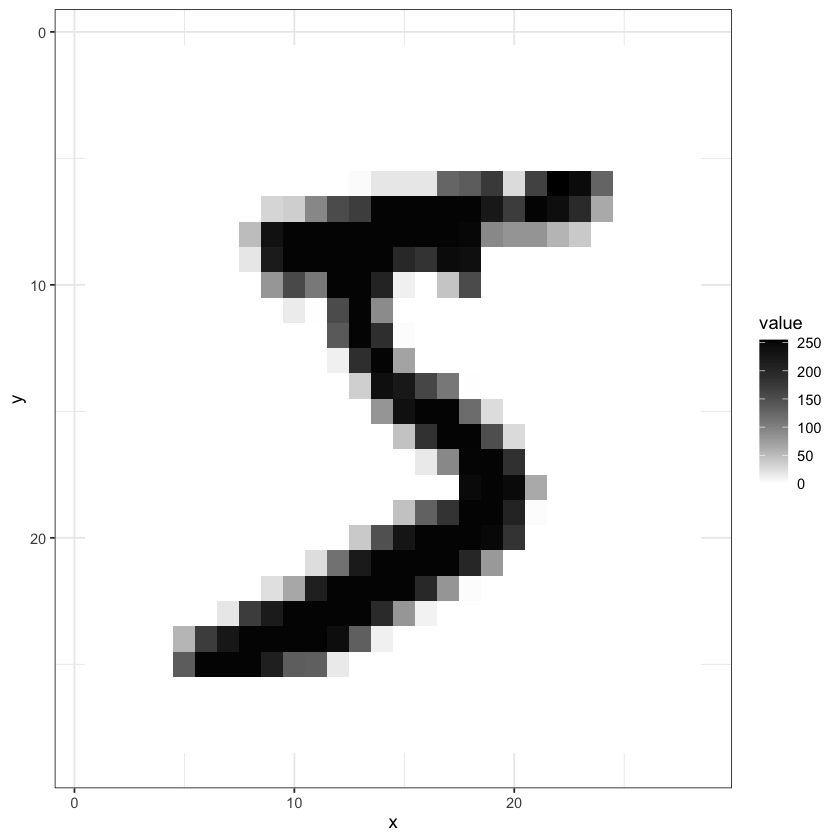

In [5]:
image_1 <- as.data.frame(x_train[1, , ]) 
colnames(image_1) <- seq_len(ncol(image_1))
image_1$y <- seq_len(nrow(image_1))
image_1 <- gather(image_1, "x", "value", -y)
image_1$x <- as.integer(image_1$x)

ggplot(image_1, aes(x = x, y = y, fill = value)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "black", na.value = NA) +
  scale_y_reverse() +
  theme_bw()

In [6]:
# Variable dependiente -> target
y_train <- mnist$train$y
head(y_train)

[1] 5 0 4 1 9 2

### Muestra de Prueba

In [7]:
x_test <- mnist$test$x


In [8]:
y_test <- mnist$test$y

### Limpieza de los datos

<div >
    <img src = "figs/Matrices.png" />
</div>

In [9]:
# reshape
x_train <- array_reshape(x_train, c(nrow(x_train), 784))
dim(x_train)

[1] 60000   784

In [10]:
x_test <- array_reshape(x_test, c(nrow(x_test), 784))

In [11]:
# rescale pixeles entre 0 y 1
x_train <- x_train / 255
x_test <- x_test / 255

## Armando la primer red

<div >
    <img src = "figs/red_neuronal.png" />
</div>

Comenzamos creando un nuevo modelo usando `keras_model_sequential()`. Esto define una arquitectura lineal: cada capa que agregamos se apilará en orden, una después de otra. 

In [12]:
model <- keras_model_sequential() 

# Definimos las capas
model %>% 
  layer_dense(units = 10, activation = 'relu', input_shape = c(784)) %>% 
  layer_dense(units = 10, activation = 'softmax')

### Dense

En una capa `layer_dense`, cada neurona está conectada a todas las neuronas de la capa anterior. Los `units`que se especifican en los parámetros, se refieren a la cantidad de neuronas que se deben incluir en una capa determinada de la red neuronal. Es decir, los units son el número de nodos de la capa. Por último, el parámetro `activation`  especifica la función de activación que se va a usar en esa capa de la red.



### Capa de salida: The softmax function

Multinomial logistic 

\begin{align}
 \Pr(Y_{i}=k)={\frac {e^{{\boldsymbol {\beta }}_{k}\cdot \mathbf {A} _{i}}}{\sum _{j=1}^{K}e^{{\boldsymbol {\beta }}_{j}\cdot \mathbf {A} _{i}}}}
\end{align}




In [13]:
beta_A<-c(1.3,2.2,0.7,1.1,2.5,7.3,3.1,4.5,1.3,1.8)

pr<-exp(beta_A)/sum(exp(beta_A))

pr

[1] 0.002248166 0.005529597 0.001233820 0.001840643 0.007464175 0.906975013
 [7] 0.013600613 0.055153207 0.002248166 0.003706600

#### Target como categóricos


<div >
    <img src = "figs/target.png" />
</div>

In [14]:
y_train <- to_categorical(y_train, 10)
y_test <- to_categorical(y_test, 10)
head(y_train)

0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0
0,0,0,0,1,0,0,0,0,0
0,1,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,1
0,0,1,0,0,0,0,0,0,0


## Modelo Final

In [15]:
summary(model)

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                     │ (None, 10)               │         7,850 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 10)               │           110 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘
 Total params: 7,960 (31.09 KB)
 Trainable params: 7,960 (31.09 KB)
 Non-trainable params: 0 (0.00 B)


## Entrenando la primera red

In [16]:
model %>% compile(
  optimizer = 'adam',
  loss = 'categorical_crossentropy',
  metrics = c('accuracy')
)

### Función de pérdida

Cross-entropy nos permite medir el error entre las probabilidades predichas y los verdaderos valores

$$
L = -\sum_{k=1}^{K} \mathbf{1}(y=k) \log \hat{p}(y=k)
$$



In [17]:
L <- -y_train[1,]*log2(0.01)

L

[1] 0.000000 0.000000 0.000000 0.000000 0.000000 6.643856 0.000000 0.000000
 [9] 0.000000 0.000000

In [18]:
sum(L)

[1] 6.643856

### Optimizador

El optimizador es el algoritmo que toma el gradiente calculado por backpropagation y decide *cómo* actualizar los pesos. El descenso de gradiente básico usa una tasa de aprendizaje fija $\epsilon$ para todos los parámetros. `Adam` va más lejos: **adapta la tasa de aprendizaje de cada parámetro por separado**, basándose en el historial de gradientes recientes. En la práctica, esto lo hace más robusto y rápido que el gradiente descendente estándar y es el optimizador por defecto en la mayoría de aplicaciones de deep learning.

[Acá pueden ver una comparación interactiva de optimizadores](https://cede.uniandes.edu.co/Optimizers/NN_%20Optimizadores.html). Para más detalles sobre `Adam` pueden ir [acá](https://machinelearningmastery.com/adam-optimization-algorithm-for-deep-learning/).

### Métrica 

Usamos `accuracy` como métrica de desempeño. 

$$
\text{accuracy} = \frac{\text{correct predictions}}{\text{total predictions}}
$$

Buscamos ver la proporción de dígitos clasificados correctamente

#### Función de pérdida vs. Métrica: ¿cuál es la diferencia?

> La función de pérdida es lo que el algoritmo optimiza; la métrica es lo que tú lees para entender qué tan bien funciona el aprendizaje.

Son dos cosas distintas que cumplen roles distintos:

| | Función de pérdida (`loss`) | Métrica (`metrics`) |
|---|---|---|
| **¿Para qué sirve?** | Guía el entrenamiento (backprop) | Monitorea el desempeño |
| **¿Quién la usa?** | El algoritmo (Adam) | El investigador |
| **¿Debe ser diferenciable?** | **Sí**  necesitamos su gradiente | No necesariamente |
| **Ejemplo** | `categorical_crossentropy` | `accuracy`, F1 |

#### ¿Por qué existe esta distinción? 

En regresión lineal esta distinción **no aparece**: la función de pérdida es el MSE y el MSE también es la métrica que reportas. Optimizas lo mismo que comunicas. 

En clasificación, la situación cambia. Lo que nos importa comunicar es la accuracy (o F1): ¿qué fracción de los dígitos clasifica correctamente? Pero esa pregunta no tiene una respuesta continua y suave; es todo o nada. Y el algoritmo necesita una superficie suave para navegar.

La solución es usar dos objetos distintos con propósitos distintos:
- Una función que el algoritmo pueda optimizar (diferenciable).
- Una métrica que los humanos puedan interpretar (no necesita ser diferenciable).

#### ¿Por qué no optimizamos directamente la accuracy?

Accuracy es una **función escalón**: o acertaste (1) o no (0). Su gradiente es cero casi en todas partes por lo que el optimizador no tendría información para actualizar los pesos.

#### ¿Cómo lo resuelve la cross-entropy?

La **cross-entropy** penaliza de forma continua y diferenciable según qué tan *segura* estaba la red cuando se equivocó:

$$L = -\sum_{k=1}^{K} \mathbf{1}(y=k) \log \hat{p}(y=k) \quad \leftarrow \text{diferenciable, usable en backprop}$$

- Si predijo $\hat{p}(y=3) = 0.99$ y era un 3 → pérdida $\approx 0$ (bien y seguro).
- Si predijo $\hat{p}(y=3) = 0.51$ y era un 3 → pérdida moderada (bien pero inseguro).
- Si predijo $\hat{p}(y=7) = 0.99$ y era un 3 → pérdida enorme (mal y muy seguro).

Esa gradación continua le da información al optimizador en cada paso. Minimizar cross-entropy no garantiza maximizar accuracy, pero en la práctica es un proxy excelente: cuando la red aprende a asignar probabilidades bien calibradas, casi siempre también clasifica correctamente.

Noten además que cross-entropy es exactamente la **log-verosimilitud negativa** del modelo multinomial — tiene una justificación probabilística sólida, no es una elección arbitraria.

#### ¿Puedo monitorear otras métricas?

En  casos, como de desbalance de clases donde la accuracy puede ser  una métrica engañosa; podemos usar el **F1** sin problemas.

## Entrenamiento

Estamos listos para entrenar la red. Comenzamos fijando una semilla aleatoria para asegurar la reproducibilidad de los resultados. Esto es importante porque el 20% de los datos de entrenamiento se reserva automáticamente **y de forma aleatoria** para validación, lo que permite monitorear el desempeño del modelo en datos no vistos. Dado que esta partición cambia en cada corrida, fijar la semilla garantiza consistencia.

A diferencia de enfoques como la validación cruzada (CV), aquí usamos una partición fija del 20% para la validación. Las redes neuronales son modelos que exigen grandes volúmenes de datos; con muchos parámetros, necesitan suficientes observaciones para ser estimadas con precisión. Si el dataset es tan pequeño, reservar el 20% resulta costoso, ya que reducir el tamaño del conjunto de validación introduce variabilidad en la estimación del error de generalización. Con $N$ grande, ese problema desaparece: por la LLN, el error estimado sobre el conjunto de validación converge al error de generalización verdadero. La diferencia es $O(1/\sqrt{N})$: con 12,000 observaciones de validación, ese ruido es del orden de 0.9%, suficientemente pequeño para que una sola partición sea informativa y CV se vuelva redundante.

A esto se suma el costo computacional: entrenar redes es intensivo, y repetir el proceso múltiples veces como exige CV puede volverse prohibitivo. 

Por eso, con suficientes datos, una partición fija del 20% ofrece un balance razonable entre precisión estadística y eficiencia computacional.


Luego, entrenamos el modelo durante 30 épocas, utilizando mini-batches de 512 observaciones.

In [19]:
set.seed(101010) # reproducibilidad


history <- model %>% fit(
  x_train, y_train,        
  epochs = 30,             # Número de veces que el modelo ve todo el dataset
  batch_size = 512,        # Tamaño del mini-batch (2^8): controla cuántos datos se usan para calcular el gradiente
  validation_split = 0.2   # Reserva el 20% de los datos de entrenamiento para validación
)

Durante el entrenamiento, el modelo sigue estos pasos:

* Recibe los datos de entrenamiento (`x_train`, `y_train`).
* Aprende a asociar entradas y salidas (por ejemplo, imágenes con etiquetas).
* Evalúa su desempeño en un conjunto de validación reservado automáticamente.

Al llamar la función `fit()`, el modelo se ajusta a los datos. En este ejemplo especificamos dos hiperparámetros clave: `epochs` y `batch_size`

- Un `epoch` es una pasada **completa** del conjunto de entrenamiento a través de la red. Es decir, todos los datos se procesan una vez, tanto hacia adelante (forward pass, donde calculamos las predicciones) como hacia atrás (backpropagation). Dentro de cada epoch, los pesos se actualizan $\lfloor N_{train} / \text{batch\_size} \rfloor$ veces, una por cada mini-batch. El número de épocas define cuántas veces se repite este proceso.


- El `batch size` determina cuántas muestras se procesan antes de actualizar los pesos del modelo. En lugar de calcular el gradiente con todo el dataset (batch gradient descent) o con una sola observación (stochastic gradient descent), usamos mini-batches. En este ejemplo, se usan bloques de 512 observaciones. Recordemos
    - `batch_size = 1`: es **Stochastic Gradient Descent (SGD)** → más ruido.
    - `batch_size = nrow(X)` (todo el dataset): es **Batch Gradient Descent** → estable pero lento.
    - `batch_size =2^k` (valores típicos: 32, 64, 128, 256, 512): es **Mini-batch Gradient Descent**, combina velocidad y estabilidad. (GPUs trabajan mejor con potencias de 2)


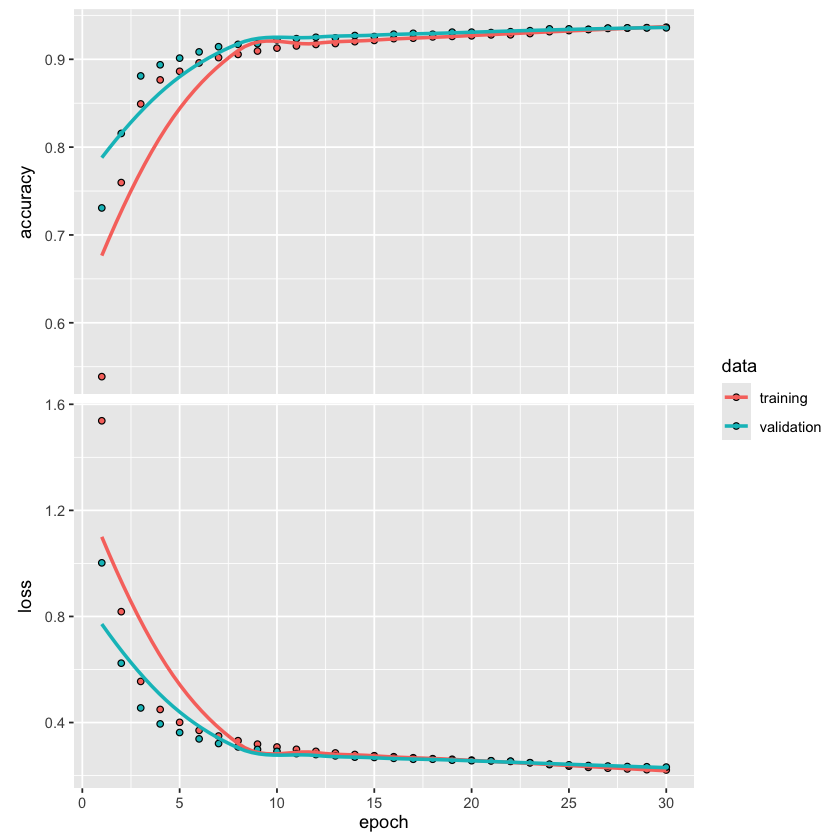

In [20]:
plot(history)

In [21]:
eval1 <- model %>% evaluate(x_test, y_test)
eval1

$accuracy
[1] 0.9333

$loss
[1] 0.2319353

In [22]:
y_hat <- model  %>% predict(x_test) %>% op_argmax(., axis = -1) #categoría con probabilidad mas alta
y_hat

tf.Tensor([8 3 2 ... 5 6 7], shape=(10000), dtype=int32)

*NB*: Un [tensor](https://es.wikipedia.org/wiki/Tensor) es una generalización de vectores y matrices a más dimensiones, y es el formato que usan las redes neuronales para trabajar con datos. Las librerías de machine learning utilizan tensores porque permiten realizar muchas operaciones numéricas de forma eficiente (por ejemplo, en paralelo o usando GPUs)

In [23]:
as.numeric(y_hat)


[1]  8  3  2  1  5  2  5 10  7 10  1  7 10  1  2  6 10  8  4  5 10  7  7  6
   [25]  5  1  8  5  1  2  4  2  4  1  8  3  8  2  4  2  2  8  5  3  4  6  2  3
   [49]  5  5  7  4  6  6  7  1  5  2 10  6  8  9 10  4  8  5  3  5  4  1  8  1
   [73]  3 10  2  8  4  3 10  8  8  7  3  8  9  5  8  4  7  2  4  7 10  4  2  5
   [97]  2  8  7 10  7  1  6  5 10 10  3  2 10  5  9  8  4 10  8  5  5  5 10  3
  [121]  6  5  8  7  8 10  1  6  9  6  7  7  6  8  9  2  1  2  7  5  7  8  4  2
  [145]  8  2  9  3  1  3 10  9  6  6  2  6  7  1  4  5  5  7  6  5  7  6  5  6
  [169]  2  5  5  8  3  4  3  8  2  9  2  9  2  9  6  1  9 10  3  6  1  2  2  2
  [193]  1  4  1  4  2  7  5  3  4  7  2  2  2  4 10  6  3 10  5  8 10  4 10  1
  [217]  4  7  6  6  8  3  3  8  2  3  9  5  2  8  4  4  9  9  8 10  3  3  5  2
  [241]  6  9  9  8  3  4  1  3  5  3  5  2 10  6  8  8  3  9  3  1  9  6  8  8
  [265] 10  2  9  2  9  1  4  1  2 10 10  5  2  9  3  2  3 10  8  6 10  3  7  5
  [289]  2  6  5  3 10  3  1  5  1  1  3  9  7  8  2  3  5  1  3  8  5  4  4  1
  [313]  1  4  2 10  7  6  4  6  8  8 10  4  1  5  3  1  8  2  2  3  2  6  4  4
  [337] 10  8  9  7  4  7  2  4  9  2  1  6  2  4  2  6  1  7  2  9  6  2  8 10
  [361]  5  7  4  3  6  1  7  6  7  4  8  3  1  9  9  6  5  2  2  5  1  8  4  8
  [385]  7  2  7  3  2 10  3  9  7  2 10  6  3  6  5  5  3  9  4  6  3  5  6  1
  [409]  4  2  8  8  4  8 10  8  2 10  3  2  5  3 10  3  1  5 10  2  5  9  2  9
  [433]  5  6 10  8  9  4  8  7  1  1  4  1  3  1  7  5 10  4  4  4  3  4 10  2
  [457]  3  7  9  1  6  7  7  7  4  9  9  3  8  6  9 10  7  2  9  5  2  3  9  4
  [481]  2 10  8  6  5  1  9 10 10  2  7  6  3  4  8  1 10  5  1  7  4 10  4  3
  [505]  2  4  2  6  7  6  3  2  3  3  7  9  3  7  6  5  9 10  8  2  4  1  4  9
  [529]  3  2 10  4  5  5  7  5  3  2  9  3  6  5  9  4  5  1  1  3  4  3 10  2
  [553]  1  9  8  5  5  8 10  7 10  1 10  9  1 10  7  1  7  6  6 10  9  4  4 10
  [577]  4  4  3  8  9  1  3  9  2  8  1  7  6  5  4  4  1 10  7  4  9  7 10 10
  [601]  7  9  7  9  6 10  9  7  1  3  5  1  3  9  4  2 10  8  6  9  1  9  5  7
  [625]  3  7  8 10 10  7 10  9  3  3 10  3  8  4  6 10  2  9  1  3  1  6  3  2
  [649]  4  8  7  8  2  3  6  9  1  4  8  9  5  1 10  2  9  7  8  8  5  4  5 10
  [673]  2 10  6  2  8  4 10  8  7 10  2  4  3  9  4  4  7 10  3  5  6  9  6  2
  [697]  2  5  5  4  2  1  8  8  1  8 10 10  5  9  6  6  5  1  9  3  2  7  9  5
  [721]  9  1  5  1  7  2  8  4  9  7  8  3  7 10  4  2  5  7  3  6 10  3  1  7
  [745]  3  2  8  4  5  2  1  6  5  4  2  2  8  5 10 10 10  9  5  1  3  5  6  2
  [769]  2  7  5  8  2 10  5  3  5  2  6  6  4  9  4  2  5  6  7  9 10  5  2 10
  [793]  4  9  1  4  3  6  2  3  9  4  5  5  1  9  9  4  4  2  8  4  6 10  7  4
  [817]  3  7  2  4  7  1  8  3  2  8  2  5  3  9  3  2  8 10  7  2  2  3  5  4
  [841]  2  8  8  5  8  1  8  4  2  4  2  1  8  8  1  4  6  6  3  8  7  7 10  3
  [865]  9  4  6  3  3  6  7  1  9  3 10  3  9  9  9  9  8 10  8  4  1  7  7  4
  [889]  3  2  4  3  3 10  4  1  1  6  3  9  2  5  5  7  1  3 10  2  5  8  5  8
  [913]  4 10  9  9  5  8  2  3  2  3  3  4  8  4  3  4 10  2  8  5  1  4  6  6
  [937]  9  7  6  1  7  8  7  7  4  3  8  9  2  2  3  5  7  5 10  6  7  4  4  5
  [961]  8  9 10  2  2  1 10  2  5  5  6  5  1  7  3  3  4  2  6  2  3  1  9  9
  [985]  2  3  7  8  2  7  3  4 10  1  2  3  3  1  9  8 10  1  3  4  2 10  8  9
 [1009]  2  1  5  2 10 10  6  5  3  3  9  2  4  8  6  5  5  2  9  2  6  9  2  3
 [1033]  9  9  1  7  3  2  2 10  2  6  4  5  9 10  6  1 10  3  3  5  9  3  2  8
 [1057]  3  5 10  5  5  1 10 10  3  3  4  4  5  4  6  8  4  6  9  2  3  5  5  7
 [1081]  5 10  6  2  1  7 10  6 10  6 10  8  4  9  1  4 10  2  4  7  8  3  6 10
 [1105]  8 10  7  4  7  4  8  5  7  6  9  6  5  8  9  4  9  1  8  7  6  9  8  4
 [1129]  4  2 10  6  3  8  4  6  2  2  3  2  5  8  5  8  6  5  6  5  1  9  4  7
 [1153] 10  7  1  3  8  5  5  5  5  7  7  5  8 10  4  5  6  6  9  8  4  8  3  8
 [1177]  1  3  5  2  2  2  9 10  3  9  8  3  1  2  6 10  5  2 10  1  7  1  5  7
 [12

In [24]:
confusionMatrix(data = factor(as.numeric(y_hat), levels = 0:9), 
  reference = factor(mnist$test$y, levels = 0:9))

Confusion Matrix and Statistics

          Reference
Prediction    0    1    2    3    4    5    6    7    8    9
         0    0    0    0    0    0    0    0    0    0    0
         1  954    0    9    2    2    6   11    2    4    8
         2    0 1111    2    1    2    5    3   11    9    7
         3    1    1  950   15    9    2    9   24    6    1
         4    1    3   15  930    1   18    0    5   21   16
         5    0    0   12    0  924    6    7    6    9   20
         6    8    2    2   26    0  803   12    2   21    8
         7   11    5    9    1    6   10  910    0    7    0
         8    2    1   10   11    3    6    0  943   11   18
         9    2   12   21   16    6   26    6    2  883    6

Overall Statistics
                                          
               Accuracy : 0.0059          
                 95% CI : (0.0044, 0.0077)
    No Information Rate : 0.1263          
    P-Value [Acc > NIR] : 1               
                                         

## Teorema de Aproximación Universal y Redes Profundas


### ¿Por qué funcionan las redes neuronales?

Un aspecto clave del diseño de redes neuronales es determinar la **arquitectura**: cuántas unidades debe tener la red y cómo deben conectarse entre sí.

El **Teorema de Aproximación Universal** (Cybenko, 1989; Hornik, Stinchcombe & White, 1989) garantiza que, independientemente de qué función queramos aprender, una red suficientemente grande puede representarla. Formalmente, una red con una sola capa oculta y suficientes unidades puede aproximar cualquier función continua $f^*: \mathbb{R}^p \to \mathbb{R}$ con precisión arbitraria:

$$f(X) = \beta_0 + \sum_{k=1}^{K} \beta_k \, g\!\left(w_{k0} + \sum_{j=1}^{p} w_{kj} X_j\right)$$

*NB: el mismo Halbert White del os errores estándar robustos a la heteroscedasticidad es coautor del paper de 1989.*

En principio, una sola capa oculta es suficiente. Entonces, ¿para qué agregar más capas?

### ¿Por qué redes profundas?

El teorema garantiza que la función *existe*, pero el aprendizaje puede fallar por dos razones distintas:

1. **El algoritmo de optimización puede no encontrar los parámetros correctos.** La superficie de pérdida no es convexa y puede tener mínimos locales, puntos silla y regiones planas. Una red de una sola capa muy ancha es difícil de optimizar en la práctica.

2. **El algoritmo puede elegir la función incorrecta por sobreajuste.** Con demasiados parámetros concentrados en una sola capa, el riesgo de memorizar el training set es alto.

Las redes profundas mitigan ambos problemas: distribuyen la complejidad en múltiples capas, lo que hace la optimización más manejable y reduce el sobreajuste relativo al número de parámetros totales.

## Arquitectura de redes y capas múltiples

<div >
    <img src = "figs/red_neuronal_2.png" />
</div>

In [25]:
model2 <- keras_model_sequential() 

model2 %>%
layer_dense(units = 256, activation = 'relu', input_shape = c(784)) %>% 
layer_dense(units = 128, activation = 'relu') %>%
layer_dense(units = 10, activation = 'softmax')

In [26]:
summary(model2)

Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                   │ (None, 256)              │       200,960 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_3 (Dense)                   │ (None, 128)              │        32,896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_4 (Dense)                   │ (None, 10)               │         1,290 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘
 Total params: 235,146 (918.54 KB)
 Trainable params: 235,146 (918.54 KB)
 Non-trainable params: 0 (0.00 B)


In [27]:
model2 %>% compile(
  optimizer = 'adam',
  loss = 'categorical_crossentropy',
  metrics = c('accuracy')
)

In [28]:
set.seed(101010)
history2 <- model2 %>% fit(
  x_train, y_train, 
  epochs = 8, 
  batch_size = 128,
  validation_split = 0.2
)

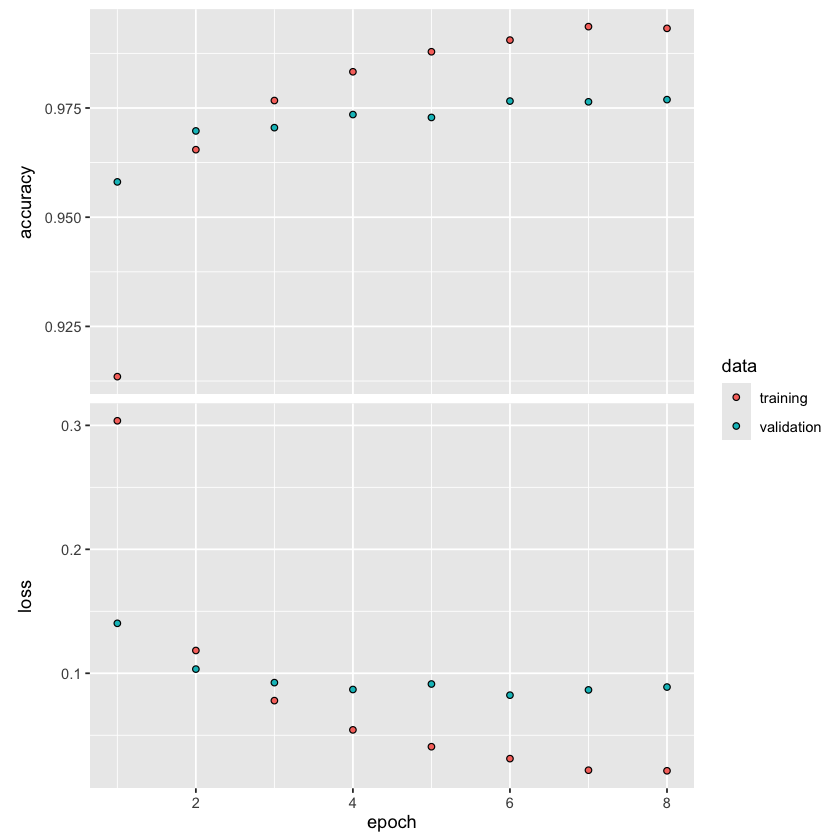

In [29]:
plot(history2)

### Overfitting

Veamos el gráfico anterior. Hay dos líneas clave son:

- **Training** en el conjunto de **entrenamiento**: tiende a mejorar siempre.
- **Validation** en el conjunto de **validación** : mejora al principio, pero puede estancarse o empeorar.

**Si hay una brecha creciente entre ambas curvas → overfitting**: el modelo está memorizando el conjunto de entrenamiento en lugar de generalizar.

En redes profundas, el riesgo de sobreajuste es alto porque el número de parámetros puede ser enorme. Para esta red (784 → 256 → 128 → 10):

$$784 \times 256 + 256 + 256 \times 128 + 128 + 128 \times 10 + 10 = 234{,}250 \text{ parámetros}$$

Con 60,000 imágenes esto es manejable, pero el riesgo siempre existe. Necesitamos **regularización**.

In [30]:
eval2 <- model2 %>% evaluate(x_test, y_test)
eval2

$accuracy
[1] 0.9776

$loss
[1] 0.07749684

## Regularización en Redes Neuronales

El sobreajuste en redes profundas se controla con las mismas ideas que ya conocen de modelos lineales, adaptadas al contexto de las redes:

### L1, L2 y Elastic Net (Weight Decay)

Exactamente análogas a Lasso, Ridge y Elastic Net: se agrega una penalización sobre los pesos $W$ a la función de pérdida:

$$L_{\text{reg}}(\theta) = L(\theta) + \lambda \|W\|_2^2 \quad (\text{L2 / Ridge})$$

$$L_{\text{reg}}(\theta) = L(\theta) + \lambda \|W\|_1 \quad (\text{L1 / Lasso})$$

$$L_{\text{reg}}(\theta) = L(\theta) + \lambda_1 \|W\|_1 + \lambda_2 \|W\|_2^2 \quad (\text{Elastic Net})$$

En la práctica, Elastic Net suele dominar a L1 o L2 solos en redes neuronales.

En `keras` se aplican así dentro de cada `layer_dense`:

```
# L2
kernel_regularizer = regularizer_l2(0.001)

# L1
kernel_regularizer = regularizer_l1(0.001)

# Elastic Net
kernel_regularizer = regularizer_l1_l2(l1 = 0.001, l2 = 0.001)
```

Sin embargo, en redes muy profundas estas penalizaciones son difíciles de calibrar capa por capa. Esto motivó técnicas específicas para redes neuronales como Dropout y Early Stopping.

### Early Stopping y Dropout

Técnicas diseñadas específicamente para redes neuronales, más flexibles y empíricamente más efectivas en arquitecturas profundas.

#### Early Stopping

La pregunta práctica más frecuente en redes neuronales es: **¿cuántas épocas entreno?**

- Pocas épocas → underfitting: el modelo no aprendió suficiente.
- Muchas épocas → overfitting: el modelo memorizó el training set.

**Early stopping** resuelve esto automáticamente: monitorea la pérdida en validación y **detiene el entrenamiento cuando deja de mejorar**, sin necesidad de fijar el número de épocas de antemano.

```
val_loss
   │
   │  ↘
   │    ↘
   │      ↘__         ← mínimo: mejor modelo
   │          ‾↗↗↗    ← empeora: aquí para
   └────────────────── épocas
         ↑
      patience
```

Los parámetros clave son:

- **`monitor`**: qué métrica observar (generalmente `la pérdida en validación`).
- **`patience`**: cuántas épocas sin mejora tolerar antes de parar. Un valor de 5–10 es razonable; muy bajo se detiene prematuramente, muy alto pierde el punto.
- **`restore_best_weights = TRUE`**: al terminar, restaura los pesos del mejor epoch (no del último). Esto es crucial (sin esto, el modelo final sería el del epoch donde ya empezó a sobreajustar).

Early stopping puede verse como una forma implícita de regularización: limita la capacidad del modelo de memorizar el training set al cortar el entrenamiento antes.


Entrenamiento detenido en época: 11 de 100


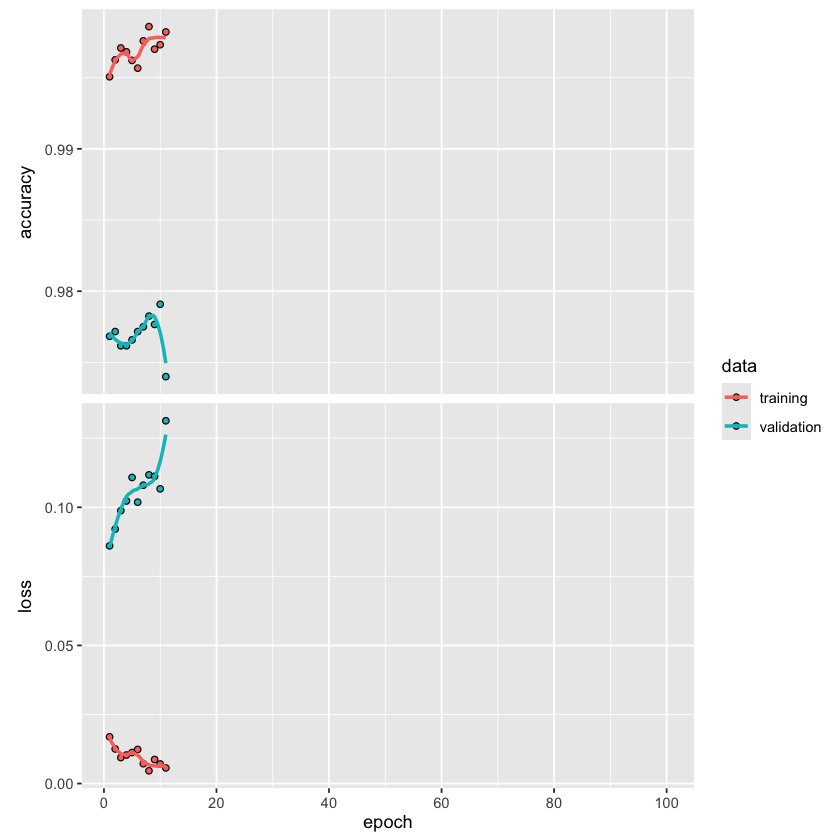

In [31]:
# Early stopping: entrenamos model2 con hasta 100 épocas
# pero dejamos que el callback decida cuándo parar

early_stop <- callback_early_stopping(
  monitor              = "val_loss",  # observamos la pérdida en validación
  patience             = 10,          # toleramos 10 épocas sin mejora
  restore_best_weights = TRUE         # volvemos al mejor modelo al terminar
)

set.seed(101010)
history2_es <- model2 %>% fit(
  x_train, y_train,
  epochs           = 100,        # máximo posible —> early stopping decide
  batch_size       = 128,
  validation_split = 0.2,
  callbacks        = list(early_stop),
  verbose          = 1
)

cat("\nEntrenamiento detenido en época:", length(history2_es$metrics$val_loss), "de 100\n")
plot(history2_es)


#### Dropout Learning

Esta es una forma de regularización relativamente nueva y eficiente. Inspirado en los random forest, la idea es eliminar aleatoriamente una fracción $\phi$ de las unidades en una capa al calcular los pesos del modelo (sucede entonces cada vez que se calcula un peso). 

Las unidades sobrevivientes sustituyen a las que faltan y sus pesos aumentan en un factor de 1/(1 − φ) para compensar. Esto evita que los nodos "se especialicen demasiado", llevando a sobreajuste.

Puede verse como una forma de regularización; efectivamente, estamos encogiendo ciertos pesos (nodos) a cero, mientras se mantiene intacta la arquitectura.

In [32]:
model3 <- keras_model_sequential() 

model3 %>%
layer_dense(units = 256, activation = 'relu', input_shape = c(784)) %>% 
layer_dropout(rate = 0.4) %>%
layer_dense(units = 128, activation = 'relu') %>%
layer_dropout(rate = 0.3) %>%
layer_dense(units = 10, activation = 'softmax')

In [33]:
model3 %>% compile(
  optimizer = 'adam',
  loss = 'categorical_crossentropy',
  metrics = c('accuracy')
)

In [34]:
summary(model3)

Model: "sequential_2"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                   │ (None, 256)              │       200,960 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_6 (Dense)                   │ (None, 128)              │        32,896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_7 (Dense)                   │ (None, 10)               │         1,290 │
└─────

In [35]:
set.seed(101010)
history3 <- model3 %>% fit(
  x_train, y_train, 
  epochs = 30, 
  batch_size = 128,
  validation_split = 0.2
)

In [36]:
eval3 <- model3 %>% evaluate(x_test, y_test)
eval3

$accuracy
[1] 0.9817

$loss
[1] 0.08238067

## Otras arquitecturas: Convolutional Neural Networks

En nuestro análisis inicial de imágenes, usamos una red neuronal de múltiples capas (MLP). Para eso, aplanamos cada imagen: una matriz de $28 \times 28$  en un vector de 784 elementos, y luego la pasamos por capas completamente conectadas.

Sin embargo, existen otras arquitecturas que aprovechan mejor la **estructura espacial** de las imágenes. Las redes convolucionales (CNN) incorporan capas especializadas que permiten construir modelos **más compactos**, con **menos parámetros** y, en muchos casos, con **mejor desempeño**.

Comenzamos creando un nuevo modelo con `keras_model_sequential()`, que mantiene una arquitectura secuencial. A esta le agregamos dos tipos de capas nuevas:

- **`conv_2d`**: detectan patrones visuales locales como bordes y formas.
- **`max_pooling_2d`**: reducen la dimensionalidad y el ruido, conservando la información más relevante.

Después de estas transformaciones, "aplanamos" nuevamente los datos para pasarlos por la parte final de la red:

- **`flatten`**: convierte los mapas de activación en un vector.
- **`dense`**: realiza la clasificación final en 10 clases usando `softmax`.

Entre capas, también agregamos algo de **`dropout`**, que ayuda a prevenir el sobreajuste, como quien dice, “salpicado” a lo largo del modelo.

Voy a implementar una version un poco modificada de  *LeNet* (1998). Esta fue una de las primeras CNN que ganó gran reconocimiento por su desempeño en tareas de visión por computadora. Este modelo fue introducido (y nombrado) por Yann LeCun, entonces investigador en AT&T Bell Labs, con el propósito de reconocer dígitos escritos a mano en imágenes  

En su momento, LeNet logró resultados extraordinarios para la época y, con el tiempo, se adaptó para reconocer dígitos en el procesamiento de depósitos en cajeros automáticos. ¡A día de hoy, algunos cajeros automáticos aún ejecutan el código que Yann LeCun y su colega Léon Bottou desarrollaron en los años 90!

### ¿Por qué CNN? 

En los modelos anteriores **aplanamos** cada imagen de $28 \times 28$ en un vector de 784 elementos. Esto destruye la **estructura espacial**: dos píxeles vecinos no tienen más relación entre sí que dos píxeles en extremos opuestos de la imagen.

Una **Red Convolucional (CNN)** preserva esa estructura aplicando **filtros** (kernels) que se deslizan sobre la imagen:

<div >
    <img src = "figs/cnn_outline.png" />
</div>

- Cada filtro detecta un **patrón local** (borde horizontal, curva, textura).
- La red **aprende** qué filtros son útiles.
- La capa `layer_max_pooling_2d` reduce la resolución y hace el modelo más robusto a pequeñas traslaciones.

Resultado: **menos parámetros**, **mejor uso de la estructura espacial**, **mayor precisión**.

In [37]:
# Input image dimensions
img_rows <- 28
img_cols <- 28

x_train <- array_reshape(x_train, c(nrow(x_train), img_rows, img_cols, 1))
x_test <- array_reshape(x_test, c(nrow(x_test), img_rows, img_cols, 1))
input_shape <- c(img_rows, img_cols, 1)


cnn_model <- keras_model_sequential() 

cnn_model %>%
  layer_conv_2d(filters = 32, kernel_size = c(3,3), activation = 'relu', input_shape =input_shape) %>% 
  layer_max_pooling_2d(pool_size = c(2, 2)) %>% 
  layer_conv_2d(filters = 64, kernel_size = c(3,3), activation = 'relu') %>% 
  layer_max_pooling_2d(pool_size = c(2, 2)) %>% 
  layer_dropout(rate = 0.25) %>% 
  layer_flatten() %>% 
  layer_dense(units = 128, activation = 'relu') %>% 
  layer_dropout(rate = 0.5) %>% 
  layer_dense(units = 10, activation = 'softmax')

Una vez definida la arquitectura, el siguiente paso es compilar:

In [38]:
cnn_model %>% compile(
   optimizer = 'adam',
  loss = 'categorical_crossentropy',
  metrics = c('accuracy')
)


In [39]:
summary(cnn_model)

Model: "sequential_3"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                   │ (None, 26, 26, 32)       │           320 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 13, 13, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 11, 11, 64)       │        18,496 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 5, 5, 64)         │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_2 (Dropout)               │ (None, 5, 5, 64)         │             0 │
├─────

Entrenamos:

In [40]:
set.seed(101010)
cnn_history <- cnn_model %>% fit(
  x_train, y_train, 
  epochs = 10, 
  batch_size = 128,
  validation_split = 0.2
)

Evaluamos en el conjunto de prueba:

In [41]:
eval4 <- cnn_model %>% evaluate(x_test, y_test)
eval4

$accuracy
[1] 0.9919

$loss
[1] 0.02488382

## Resumen comparativo de arquitecturas

Evaluamos los cuatro modelos en el mismo conjunto de prueba (10,000 imágenes de MNIST).

In [42]:
# Comparación de todos los modelos en el test set
results <- data.frame(
  Modelo          = c("1: Single Layer (10 nodos)",
                      "2: Deep MLP (256→128→10)",
                      "3: Deep MLP + Dropout",
                      "4: CNN"),
  Parametros      = c("~7.9K", "~235K", "~235K", "~225K"),
  Regularizacion  = c("Ninguna", "Ninguna", "Dropout (0.4, 0.3)", "Dropout + Conv"),
  Accuracy_Test   = round(c(eval1$accuracy, eval2$accuracy,eval3$accuracy,eval4$accuracy), 4)
)

print(results, row.names = FALSE)

                     Modelo Parametros     Regularizacion Accuracy_Test
 1: Single Layer (10 nodos)      ~7.9K            Ninguna        0.9333
   2: Deep MLP (256→128→10)      ~235K            Ninguna        0.9776
      3: Deep MLP + Dropout      ~235K Dropout (0.4, 0.3)        0.9817
                     4: CNN      ~225K     Dropout + Conv        0.9919


La arquitectura convolucional es mucho más adecuada para procesar imágenes que la red neuronal densa que usamos inicialmente. Esto resalta la importancia de elegir la arquitectura correcta según el problema. Para datos tabulares estructurados, las redes feedforward profundas son una opción válida y funcionan bien a gran escala, aunque en la práctica modelos como XGBoost suelen ser competitivos, especialmente con datasets de tamaño moderado. La ventaja de las redes aparece cuando N es muy grande o cuando la estructura del problema (imágenes, texto, audio) justifica arquitecturas especializadas.

Incluso en un problema relativamente sencillo como el de dígitos, el salto respecto a las redes feedforward profundas es grande, y esto es apenas el comienzo. Existen arquitecturas aún más sofisticadas que pueden mejorar aún más el desempeño, especialmente en tareas más complejas:

- **Redes más profundas** (como VGG o ResNet), que aprenden jerarquías de características.
- **Redes convolucionales con atención**, que enfocan el procesamiento en regiones relevantes.
- **Modelos preentrenados** y transferencia de aprendizaje, que permiten aprovechar redes entrenadas sobre grandes datasets.

En cursos más avanzados verán otras arquitecturas más complejas que se adaptan mejor a problemas específicos. Esto es solo la superficie.